# Overfitting

One of the most important issues in Machine Learning is to understand the difference between training and testing errors. The training process will allow the ANN parameters (weights and bias) to be modified to minimise the loss in the **set of patterns used for training**.  If this set of patterns is sufficiently representative, then the ANN will perform well in its working environment, i.e. with new patterns that are not in the training set.  On the other hand, if this set of patterns has not been well chosen, the ANN could not work well with new patterns.  The only way to know this is precisely to evaluate the ANN with new patterns and calculate the error with these **test patterns**.  Since the test set is available from the beginning, this evaluation with the test set is done at the same time as with the training set (but only the training set is used for training). 

Therefore, to assess how well trained an ANN is, this can be done by evaluating the test set, not the training set.  Usually there is only one set of data, so it is usually divided into two subsets: training and test. There are several alternatives to perform this division; in these tutorials, two different ones will be performed: 

* **Hold Out**. In this method, an experiment is performed with a simple partition of the data set, leaving a certain percentage for testing, usually between 20% and 30%. 

* **Cross-validation**.  Here, the data set is divided into $k$ disjoint subsets in order to perform the corresponding $k$ experiments.  In the k-th experiment, the $k$-th set is separated for testing, and trained with the remaining $k-1$.  A usual value of $k$ is 10, so you have a 10-fold crossvalidation.

More specifically, in this session we will focus on the first one, leaving the second one for a later one.  The hold out technique allows us to split the data set into two subsets: training and test.  The training subset allows to adjust the parameters of the model (connection weights and bias), while the test subset allows to check (test) the behavious of a trained ANN (or, any kind of model that is being used, such as a decision tree) on new patterns, not present in the training set.

![Normal training in the left, and an overfitting curve on the right](./img/Overfitting.png)

Given a well-chosen (and therefore sufficiently representative) training set, the training process could be similar to the figure on the left, with both training and test errors decreasing with each cycle. However, in general, it cannot be ensured that the training set is as noise-free and well-chosen as desirable, so that **overtraining** or **overfitting** often occurs during training.  This can be clearly seen in the figure on the right, where both errors are decreasing until a point is reached where the test error starts to increase.   From that point on, the system starts to overfit. 

To avoid overfitting, in ANNs there are a series of techniques known as regularisation techniques, each of which is very different in nature, but all of which aim to avoid overtraining.  Although these techniques are dealt with in much greater depth in other subjects in the programme, e.g. Deep Learning I, in these tutorials we are going to study one of the most well-known techniques, seen in the theory session, called Early Stopping. 

In this technique, instead of dividing the initial set of samples into 2 subsets, we create 3 subsets: training, validation and test.  The training and test sets perform the functions described above. The purpose of the validation set is to avoid overfitting by controlling the training process, but it is not used to modify weights or bias.  There are several ways to control the training process, here we will use two of them together:

* A new criteria for stopping the training process.   With the definition of a new parameter: the maximum number of consecutive cycles without improving the *loss* in the validation set.  If these cycles elapse without improving the best validation *loss* achieved so far, the training is stopped.  As the validation set is not used to modify weights or bias, it gives an estimate of what the test error could be.  Therefore, when the validation error increases, it increases the error in patterns that it has not seen, so it is estimated that the test error would increase, and the network would be overtraining.


* Once the training process has stopped, the validation set determines which network is returned.  During all the training cycles, the loss is calculated in the training set, which is necessary to modify weights and bias, but also in the validation set.   Once the training is stopped, the ANN is returned corresponding not to the last cycle, but to the cycle with the lowest error in the validation set.  This is done because it is estimated that this ANN is the one that will give the lowest error in the test set, i.e. the one that will behave better with new patterns and, consequently, the one that will generalise better. 

Once the training process has stopped and an ANN has been returned, the test set can be evaluated to assess how well the ANN has been trained. 

> **Important**: The errors (or accuracies, or any metric used) in the training and validation sets are interesting, but the one that really matters is the test set. 

However, most of the time you have all 3 sets (training, validation and test) from the beginning, so as you evaluate the training and validation sets, you also evaluate the test set, which is useful for plotting graphs. However, these values in the test set cannot be used for decision making. 

### Question 3.1
> ❓ If what we want to achieve is an ANN with the lowest possible test error, why not choose the ANN corresponding to the cycle with the lowest test error?

`Because the test set must never be used during training or model selection. Its purpose is to provide an unbiased estimate of how the ANN will perform on unseen, real-world data.
If we want an ANN with the lowest possible test error, we cannot choose the model based on the test set because the test set must only be used at the very end, to give an unbiased estimate of performance on unseen data. If we pick the model with the lowest test error during training, we are leaking information from the test set into the training process. This leads to overfitting to the test data and gives an unrealistically optimistic estimate of generalization. The correct procedure is to train on the training set, use the validation set to select the best model or apply early stopping, and then evaluate the chosen model on the test set only once.`

Therefore, in the training loop it is necessary to keep a reference to the best validation error found so far.  It is also necessary to keep a copy of the ANN that has given that validation error.  Both elements should be updated every cycle when the validation error improves. It is also necessary to keep a counter of how many consecutive cycles the validation error has not improved.

As can be seen, the test set cannot have any involvement in the training process. This is the right thing to do, since an ANN with completely new patterns is being evaluated. However, from a very strict point of view, there is one part in this whole process where the test set is having a small influence: in the normalisation of the data.

Usually the starting point is a dataset that is first normalised and then split into training/test.  If this is done in this way, the patterns used for testing have some influence on the calculation of the normalisation parameter values, which would not be correct. However, the impact they usually have on these parameters and in general on the performance of the ANN is so low, that this is usually not taken into account and all patterns are normalised together.  In any case, the really correct pipeline to do would be divide the data into train test, to calculate the values of the normalisation parameters only with the training set, and the applied that parameters of normalization to the test prior to run the usual training process. Addtionally, if there is a validation data, it can be used on the normalization, too.

For this assignment, you are asked to perform two sets of experiments, one without using validation and the other using a validation set.  More specifically, the requirements are: 

1. Develop a function called `holdOut` that given two parameters, `N` (equal to the number of patterns) and `P` (value between 0 and 1, indicating the percentage of patterns that will be separated for the test set), returns a tuple with two vectors with the indices of the patterns that will be used for training and testing.  The sum of lengths of both vectors has to be equal to N, and these two vectors have to be disjoint.

  This function can be done in a very simple way using the function `randperm` (to use it, load the module with `using Random`).
  
  From this function, splitting a database into two subsets is done immediately.

# 📘  Imports

In [1]:

using Random
using Statistics
using Plots
using Flux 
using Flux.Losses
using DelimitedFiles;

using Pkg; 
#Pkg.add("Plots") # --- Uncomment if Plots is not installed


# 📘  holdOut(N::Int, P::Real)


In [2]:

function holdOut(N::Int, P::Real)
    #TODO
    @assert(0.0 < P < 1.0 , "P must be in (0,1)")
    #idx = shuffle(1:N)
    idx = randperm(N)
    println("idx indices: ", idx)
    nTrain = Int(floor((1-P)*N))
    trainIdx = idx[1:nTrain]
    testIdx = idx[nTrain+1:end]
    return (trainIdx, testIdx)
end;
trainIdx, testIdx = holdOut(10, 0.1);
println("Train indices: ", trainIdx)
println("Test indices: ", testIdx)

idx indices: [3, 6, 10, 5, 8, 4, 9, 7, 2, 1]
Train indices: [3, 6, 10, 5, 8, 4, 9, 7, 2]
Test indices: [1]


2. Develop another function called `holdOut`, the same as the previous one and, based on it, which takes 3 parameters: `N` (number of patterns), `Pval` (rate of patterns in the validation set) and `Ptest` (rate of patterns in the test set), and returns a tuple with 3 vectors, with the indices of the elements of the training, validation and test sets. The sum of the lengths of these 3 vectors has to be equal to `N`.

 To do this, simply make two calls to the previously developed `holdOut` function. 

# 📘  holdOut(N::Int, Pval::Real, Ptest::Real)

In [3]:
function holdOut(N::Int, Pval::Real, Ptest::Real)     
    @assert(0.0 < Pval < 1.0 , "Pval must be in (0,1)")
    @assert(0.0 < Ptest < 1.0 , "Ptest must be in (0,1)")
    @assert(Pval+Ptest < 1.0 , "Pval + Ptest must be in lower than 1")

    train_val_idx, test_idx = holdOut(N, Ptest)

    # Compute the absolute number of validation samples as Pval * N (rounded down)
    nVal = Int(floor(Pval*N))          
    # Compute the total number of samples available for training + validation (everything except the test set)
    nTrainVal = Int(floor((1-Ptest)*N)) 
    # Recalculate the validation proportion relative to the train+validation pool
    Pval2 = nVal/nTrainVal             

    local_train_idx, local_val_idx = holdOut(length(train_val_idx), Pval2)

    # Map from local indices back to the global indices
    train_idx = train_val_idx[local_train_idx]
    val_idx   = train_val_idx[local_val_idx]

    return (train_idx, val_idx, test_idx)
end;

trainIdx, valIdx, testIdx = holdOut(10, 0.3, 0.3);
println("Train indices: ", trainIdx)
println("Validation indices: ", valIdx)
println("Test indices: ", testIdx)

idx indices: [3, 4, 8, 9, 10, 6, 1, 5, 7, 2]
idx indices: [3, 5, 1, 2, 4, 6, 7]
Train indices: [8, 10, 3, 4]
Validation indices: [9, 6, 1]
Test indices: [5, 7, 2]


3. Modify the function for training the ANN developed in the previous session to accept the following *optional* parameters in addition to those defined in the previous practice:
  - **Validation set**, of type `Tuple{AbstractArray{<:Real,2}, AbstractArray{Bool,2}}`, i.e. a tuple of 2 arrays: inputs and targets. Default value to empty arrays.
  - **Test set**, of type `Tuple{AbstractArray{<:Real,2}, AbstractArray{Bool,2}}`, i.e. a tuple of 2 arrays: inputs and targets. Default value to empty arrays.
  - **maxEpochsVal**, of type `Int`, which defines the number of cycles without improving the best validation loss found so far that have to elapse to stop training. In other words, it defines a new stop criterion. Default value should be set to 20.
  
  With these parameters, this function should implement the early stopping strategy, for which it is necessary to take care that the ANN returned at the end of the function must be: 
    - If a validation set has been given as a argument (i.e. if it is not empty), the ANN to be returned does not have to be the one being trained, but the one with the best validation error.
    - If no validation set has been passed as a parameter (i.e. if it is empty), the ANN to be returned should be the one corresponding to the last training cycle.  Consequently, the new training function should work in the same way as the previous one in case no validation set is given.
    
  Additionally, from the trained ANN, this function should return a history of the loss values obtained in the training, validation and test sets in each cycle, as a vector each.
  
  - To add elements to the end of a vector, refer to the function `push!`
  - It should be noted that the loss values obtained with the ANN with random weights, prior to training, are usually considered as cycle 0. 
  
  As stated in the previous description, it will be necessary to store the best ANN achieved so far and update it in some iterations of the loop.  To do this, you cannot simply make an assignment to a new variable, since you would only assign the pointer, which would point to the same memory address with the ANN that would be modified in the next iteration.  To make a copy of an object in such a way that all objects (and data, as in this case weights and bias) it contains are also copied, recursively, you can use the function `deepcopy`. 

# 📘 trainClassANN 

In [4]:
function trainClassANN(topology::AbstractArray{<:Int,1},  
            trainingDataset::Tuple{AbstractArray{<:Real,2}, AbstractArray{Bool,2}}; 
            # --- Requirement: optional validation dataset with default empty arrays ---
            validationDataset::Tuple{AbstractArray{<:Real,2}, AbstractArray{Bool,2}}= 
                    (Array{eltype(trainingDataset[1]),2}(undef,0,0), falses(0,0)), 
            # --- Requirement: optional test dataset with default empty arrays ---
            testDataset::Tuple{AbstractArray{<:Real,2}, AbstractArray{Bool,2}}= 
                    (Array{eltype(trainingDataset[1]),2}(undef,0,0), falses(0,0)), 
            transferFunctions::AbstractArray{<:Function,1}=fill(σ, length(topology)), 
            maxEpochs::Int=1000, minLoss::Real=0.0, learningRate::Real=0.01,  
            # --- Requirement: maxEpochsVal parameter (early stopping patience), default 20 ---
            maxEpochsVal::Int=20, showText::Bool=false) 

    # --- Unpacking datasets ---
    (inputs, targets) = trainingDataset
    (val_inputs, val_targets) = validationDataset
    (test_inputs, test_targets) = testDataset

    # --- Ensures dataset dimensions match ---
    @assert size(inputs,1) == size(targets,1)
    @assert size(val_inputs,1) == size(val_targets,1)
    @assert size(test_inputs,1) == size(test_targets,1)

    # --- Requirement: build ANN with given topology ---
    ann = buildClassANN(size(inputs,2), topology, size(targets,2))

    # --- Define loss function (binary or multi-class) ---
    # discriminates based on the number of output neurons
    loss(model,x,y) = (size(y,1) == 1) ? Losses.binarycrossentropy(model(x),y) : Losses.crossentropy(model(x),y)

    # --- Requirement: loss histories for training/validation/test ---
    trainingLosses = Float32[]
    validationLosses = Float32[]
    testLosses = Float32[]

    # --- Initial losses (cycle 0, before training) ---
    numEpoch = 0
    trainingLoss = loss(ann, inputs', targets')
    push!(trainingLosses, trainingLoss)
    
    # init message buffer
    log_message = []
    log_message = "Epoch $numEpoch - loss: $(round(trainingLoss, digits=4))"


    # --- if validation set is provided ---                          
    if size(val_inputs,1) > 0
        validationLoss = loss(ann, val_inputs', val_targets')
        push!(validationLosses, validationLoss)

        # update message buffer
        log_message *= " - val_loss: $(round(validationLoss, digits=4))"
    end

     # --- if test set is provided ---  
    if size(test_inputs,1) > 0
        testLoss = loss(ann, test_inputs', test_targets')
        push!(testLosses, testLoss)
        # update message buffer
        log_message *= " - test_loss: $(round(testLoss, digits=4))"
        if showText
            # do nothing
            #println("Epoch ", numEpoch, ": test loss: ", testLoss)
        end
    end

    if showText
        # print message buffer
        println(join(log_message))
    end
    # --- Optimizer setup ---
    opt_state = Flux.setup(Adam(learningRate), ann)

    # --- Requirement: variables for early stopping ---
    epochsWithoutImprovement = 0
    bestValLoss = Inf
    bestAnn = deepcopy(ann)  # Requirement: store best ANN (deepcopy to avoid overwriting)
    bestAnnEpoch = 0

    while (numEpoch < maxEpochs) && (trainingLoss > minLoss) && (epochsWithoutImprovement < maxEpochsVal)
        Flux.train!(loss, ann, [(inputs', targets')], opt_state)
        numEpoch += 1
        log_message = []
        # --- Compute training loss and store it ---
        trainingLoss = loss(ann, inputs', targets')
        push!(trainingLosses, trainingLoss)
        
        # update message buffer
        log_message = "Epoch $numEpoch - loss: $(round(trainingLoss, digits=4))"

        outputs=ann(inputs')
        outputs=classifyOutputs(outputs')
        predicted_classes = Flux.onecold(outputs')        # vector of predicted labels
        true_classes = Flux.onecold(targets')      # vector of true labels

        accuracy_train=accuracy(predicted_classes, true_classes)

        log_message *= " - acc: $(round(accuracy_train, digits=4))"

        # --- Requirement: if validation set provided, track its loss for early stopping ---
        if size(val_inputs,1) > 0
            validationLoss = loss(ann, val_inputs', val_targets')
            push!(validationLosses, validationLoss)

            # update message buffer
            log_message *= " - val_loss: $(round(validationLoss, digits=4))"

            outputs=ann(val_inputs')
            outputs=classifyOutputs(outputs')
            predicted_classes = Flux.onecold(outputs')        # vector of predicted labels
            true_classes = Flux.onecold(val_targets')      # vector of true labels

            accuracy_val=accuracy(predicted_classes, true_classes)

            log_message *= " - val_acc: $(round(accuracy_val, digits=4))"

            if validationLoss < bestValLoss
                bestValLoss = validationLoss
                epochsWithoutImprovement = 0
                bestAnn = deepcopy(ann)   # Requirement: update best ANN when improvement found
                bestAnnEpoch = numEpoch
            else
                epochsWithoutImprovement += 1
            end
        end

        # --- Requirement: also track test loss if provided ---
        if size(test_inputs,1) > 0
            testLoss = loss(ann, test_inputs', test_targets')
            push!(testLosses, testLoss)
            

            # update message buffer
            log_message *= " - test_loss: $(round(testLoss, digits=4))"

            outputs=ann(test_inputs')
            outputs=classifyOutputs(outputs')
            predicted_classes = Flux.onecold(outputs')        # vector of predicted labels
            true_classes = Flux.onecold(test_targets')      # vector of true labels

            accuracy_test=accuracy(predicted_classes, true_classes)
            test_error = 1-accuracy_test

            log_message *= " - test_acc: $(round(accuracy_test, digits=4))"
            log_message *= " - test_error: $(round(test_error, digits=4))"

        end
        
        if showText
            # update message buffer
            log_message *= " - epochsWithoutImprovement $(epochsWithoutImprovement)"
            println(join(log_message))
        end

        #print("trainingLoss > minLoss : $(trainingLoss > minLoss) \n")
        #print("epochsWithoutImprovement < maxEpochsVal : $(epochsWithoutImprovement < maxEpochsVal) \n")
    end  # closes while
    
    # --- Early stopping notice ---
    if (epochsWithoutImprovement >= maxEpochsVal) && showText
        println("⏹ Early stopping triggered after $numEpoch epochs (no improvement for $maxEpochsVal epochs).")
    end

    # --- Requirement: return the right ANN ---
    # If validation set was provided → return best ANN found
    # Otherwise → return last trained ANN
    finalAnn = size(val_inputs,1) > 0 ? bestAnn : ann

    bestEpoch = size(val_inputs,1) > 0 ? bestAnnEpoch : maxEpochs
    println("The ANN corespond to the epoch $bestEpoch")

    return finalAnn, trainingLosses, validationLosses, testLosses
end  # closes function


trainClassANN (generic function with 1 method)

4. Since there were two versions of the ANN training function (the second accepted a vector as desired outputs), modify this function in the same way so that the targets are vectors instead of arrays for the two-class classification case. Note that in this case the types of the training, validation and test sets passed as parameters will be `Tuple{AbstractArray{<:Real,2}, AbstractArray{Bool,1}}` for all three and therefore it will be necessary to call the function `reshape` on all three. 

# 📘 trainClassANN (Overload)

In [5]:
function trainClassANN(topology::AbstractArray{<:Int,1},  
        trainingDataset::Tuple{AbstractArray{<:Real,2}, AbstractArray{Bool,1}}; 
        validationDataset::Tuple{AbstractArray{<:Real,2}, AbstractArray{Bool,1}}= 
                    (Array{eltype(trainingDataset[1]),2}(undef,0,0), falses(0)), 
        testDataset::Tuple{AbstractArray{<:Real,2}, AbstractArray{Bool,1}}= 
                    (Array{eltype(trainingDataset[1]),2}(undef,0,0), falses(0)), 
        transferFunctions::AbstractArray{<:Function,1}=fill(σ, length(topology)), 
        maxEpochs::Int=1000, minLoss::Real=0.0, learningRate::Real=0.01,  
        maxEpochsVal::Int=20, showText::Bool=false)

    (inputs, targets) = trainingDataset
    (val_inputs, val_targets) = validationDataset
    (test_inputs, test_targets) = testDataset
    
    # This function assumes that each sumple is in a row
    # we are going to check the numeber of samples to have same inputs and targets
    @assert(size(inputs,1)==size(targets,1));
    @assert (size(val_inputs,1) == size(val_targets,1));
    @assert (size(test_inputs,1) == size(test_targets,1));

    trainClassANN(topology, 
        (inputs, reshape(targets, length(targets), 1)),
        (val_inputs, reshape(val_targets, length(val_targets), 1)), 
        (test_inputs, reshape(test_targets, length(test_targets), 1)),
        transferFunctions, 
        maxEpochs=maxEpochs, minLoss=minLoss, learningRate=learningRate,
        maxEpochsVal, showText);
end;


Remember to integrate the code developed in previous sessions to validate the following pipeline:

1. Load the database, having the patterns in rows and desired attributes and outputs in columns. 

2. Use the function `holdOut` to split the data set into training, validation and test with the desired percentages. These percentages can be equal to 0.  You will therefore have 6 matrices: inputs and targets in training, validation and test (some may be empty if the corresponding percentage is 0). 

3. Calculate the parameter values corresponding to the type of normalisation to be used with your data (maximum/minimum or mean/standard deviation for each attribute) from the training set only.
  * This part does not ask to normalise the training set, but to calculate the normalisation values from the training set. 
4. With these parameters for normalisation calculated in the previous step, normalise training, validation and test sets.
5. Train different architectures, and, for each one of them, draw graphs of the evolution of the training, validation and test loss values in the same graph, including cycle 0. 

In [6]:
#Develop here the corresponding code and/or in an external file
#You can load instead of copy and paste
#TODO
#--------------------------------------------------------------------------------
## Normalization functions
#--------------------------------------------------------------------------------
function calculateMinMaxNormalizationParameters(dataset::AbstractArray{<:Real,2})
    return minimum(dataset, dims=1), maximum(dataset, dims=1)
end;

#
function normalizeMinMax!(dataset::AbstractArray{<:Real,2},      
        normalizationParameters::NTuple{2, AbstractArray{<:Real,2}})
    minValues = normalizationParameters[1];
    maxValues = normalizationParameters[2];
    dataset .-= minValues;
    dataset ./= (maxValues .- minValues);
    # eliminate any atribute that do not add information
    dataset[:, vec(minValues.==maxValues)] .= 0;
    return dataset;
end;


function normalizeMinMax!(dataset::AbstractArray{<:Real,2})
    normalizeMinMax!(dataset , calculateMinMaxNormalizationParameters(dataset));
end;

function normalizeMinMax( dataset::AbstractArray{<:Real,2},      
                normalizationParameters::NTuple{2, AbstractArray{<:Real,2}}) 
    normalizeMinMax!(copy(dataset), normalizationParameters);
end;

#--------------------------------------------------------------------------------
## One-hot encoding function
#--------------------------------------------------------------------------------
function oneHotEncoding(feature::AbstractArray{<:Any,1},      
        classes::AbstractArray{<:Any,1})

    """
    Parameters
    ----------
    feature :: AbstractVector
        The input vector of categorical values to be encoded.
    classes :: AbstractVector
        The list/array of unique classes used as encoding reference.
    """
    """
    AbstractArray{<:Any,1} :
    AbstractArray → not restricted to just Vector, could be any 1-dimensional array type.
    1 → one-dimensional array (i.e. a vector).
    <:Any → element type can be any subtype of Any (which basically means no restriction at all).
    So effectively, AbstractArray{<:Any,1} is just a very general way of saying:
    👉 “Accept any 1-D array, regardless of element type.”
    """
    # Defensive: ensure feature is a vector
    # Check that all feature values exist in the set of classes
    @assert(all([in(value, classes) for value in feature]))
    
    # Number of classes
    numClasses = length(classes)
    
    # Defensive: require at least two classes
    @assert(numClasses > 1)
    
    if (numClasses == 2)
        # Special case: binary classification, use a single column
        oneHot = reshape(feature .== classes[1], :, 1)
    else
        # General case: more than two classes
        oneHot = BitArray{2}(undef, length(feature), numClasses)
        for numClass = 1:numClasses
            # Mark 1 where feature matches the class
            oneHot[:, numClass] .= (feature .== classes[numClass])
        end
    end


    """
    Returns
    -------
    AbstractArray
        A one-hot encoded array:
        - Shape (n, 1) if there are 2 classes (binary case).
        - Shape (n, numClasses) if there are more than 2 classes.
    """
    return oneHot
end

#--------------------------------------------------------------------------------
## ANN building function
#--------------------------------------------------------------------------------
function buildClassANN(numInputs::Int, topology::AbstractArray{<:Int,1}, numOutputs::Int;
                    transferFunctions::AbstractArray{<:Function,1}=fill(σ, length(topology))) 
    ann=Chain();
    numInputsLayer = numInputs;
    for numHiddenLayer in 1:length(topology)
        numNeurons = topology[numHiddenLayer];
        ann = Chain(ann..., Dense(numInputsLayer, numNeurons, transferFunctions[numHiddenLayer]));
        numInputsLayer = numNeurons;
    end;
    if (numOutputs == 1)
        ann = Chain(ann..., Dense(numInputsLayer, 1, σ));
    else
        ann = Chain(ann..., Dense(numInputsLayer, numOutputs, identity));
        ann = Chain(ann..., softmax);
    end;
    return ann;
end;   

function classifyOutputs(outputs::AbstractArray{<:Real,2}; 
                        threshold::Real=0.5) 
   numOutputs = size(outputs, 2);
    @assert(numOutputs!=2)
    if numOutputs==1
        return outputs.>=threshold;
    else
        # Look for the maximum value using the findmax funtion
        (_,indicesMaxEachInstance) = findmax(outputs, dims=2);
        # Set up then boolean matrix to everything false while max values aretrue.
        outputs = falses(size(outputs));
        outputs[indicesMaxEachInstance] .= true;
        # Defensive check if all patterns are in a single class
        @assert(all(sum(outputs, dims=2).==1));
        return outputs;
    end;
end;

function accuracy(outputs::Vector{Int64}, targets::Vector{Int64}) 
    mean(outputs.==targets);
end;


In [7]:
# 1. Load the database
dataset = readdlm("./data/iris.data",',');

"""
2. Use the function `holdOut` to split the data set into training, validation and test with the desired percentages. 
    These percentages can be equal to 0. 
    You will therefore have 6 matrices:
    inputs and targets in training, 
    validation and test (some may be empty if the corresponding percentage is 0). 
"""



trainIdx, valIdx, testIdx = holdOut(size(dataset, 1), 0.3, 0.3)
println("Train indices: ", length(trainIdx))
println("Validation indices: ", length(valIdx))
println("Test indices: ", length(testIdx))
println("Dataset size: ", size(dataset))



# 1.1. Prepare the data
inputs = convert(Array{Float32,2}, dataset[:,1:4]);
targets = dataset[:,5];
classes = unique(targets);

println("targets \n $targets \n size$(size(targets))")
println("classes \n $classes \n num classes : $(length(classes))")


# 1.2 One-hot encode targets
targets_oh = oneHotEncoding(targets, classes)
println("One-hot encoded targets size: ", size(targets_oh))


# 1.3 Create training, validation, and test sets 
train_inputs = inputs[trainIdx, :]
val_inputs   = inputs[valIdx, :]
test_inputs  = inputs[testIdx, :]

train_targets = targets_oh[trainIdx, :]
val_targets   = targets_oh[valIdx, :]
test_targets  = targets_oh[testIdx, :]

println("Train set: inputs $(size(train_inputs)), targets $(size(train_targets))")
println("Validation set: inputs $(size(val_inputs)), targets $(size(val_targets))")
println("Test set: inputs $(size(test_inputs)), targets $(size(test_targets))")


"""
3. Calculate the parameter values corresponding to the type of normalisation to be used with your data (maximum/minimum or mean/standard deviation for each attribute) from the training set only.
  * This part does not ask to normalise the training set, but to calculate the normalisation values from the training set. 
"""
min_vals, max_vals  = calculateMinMaxNormalizationParameters(inputs);

print("minimum : $min_vals \n size : $(size(min_vals)) \n");
print("maximum : $max_vals \n size : $(size(max_vals)) \n");


"""
4. With these parameters for normalisation calculated in the previous step, normalise training, validation and test sets.
5. Train different architectures, and, for each one of them, draw graphs of the evolution of the training, validation and test loss values in the same graph, including cycle 0. 
"""
# -4. Normalize datasets ---
println("Before normalization:")
println("Train set: inputs $(size(train_inputs)), targets $(size(train_targets))")
println("Validation set: inputs $(size(val_inputs)), targets $(size(val_targets))")
println("Test set: inputs $(size(test_inputs)), targets $(size(test_targets))")

# -4.1 Calculate normalization parameters only from training set ---
min_vals, max_vals = calculateMinMaxNormalizationParameters(train_inputs)

# -4.2 Apply normalization to all sets (using training set parameters) ---
train_inputs = normalizeMinMax!(train_inputs, (min_vals, max_vals))
val_inputs   = normalizeMinMax!(val_inputs, (min_vals, max_vals))
test_inputs  = normalizeMinMax!(test_inputs, (min_vals, max_vals))

println("\nAfter normalization:")

# ✅ Check  training,validation and test inputs
# ✅ Training set must map exactly to [0,1]
# ✅ We expects all normalized values to stay within [0,1], we  clip them

val_inputs  = clamp.(val_inputs, 0.0, 1.0)
test_inputs = clamp.(test_inputs, 0.0, 1.0)



# Convert to float32 for Flux compatibility


train_inputs = Float32.(train_inputs)
val_inputs = Float32.(val_inputs)
test_inputs = Float32.(test_inputs)



@assert(all(minimum(train_inputs, dims=1) .== 0))
@assert(all(maximum(train_inputs, dims=1) .== 1))

# ✅ Validation/Test should only fall within [0,1]
@assert(all(minimum(val_inputs, dims=1) .>= 0))
@assert(all(maximum(val_inputs, dims=1) .<= 1))
@assert(all(minimum(test_inputs, dims=1) .>= 0))
@assert(all(maximum(test_inputs, dims=1) .<= 1))



println("Train inputs range per feature: ", (minimum(train_inputs, dims=1), maximum(train_inputs, dims=1)))
println("Validation inputs range per feature: ", (minimum(val_inputs, dims=1), maximum(val_inputs, dims=1)))
println("Test inputs range per feature: ", (minimum(test_inputs, dims=1), maximum(test_inputs, dims=1)))



idx indices: [107, 26, 142, 117, 88, 82, 97, 114, 29, 124, 32, 74, 137, 20, 53, 59, 105, 92, 126, 132, 119, 37, 3, 67, 118, 75, 6, 45, 23, 115, 108, 83, 130, 136, 10, 116, 139, 41, 120, 50, 17, 110, 70, 104, 133, 76, 109, 12, 11, 30, 93, 55, 96, 71, 52, 91, 42, 100, 24, 44, 57, 48, 79, 145, 128, 73, 111, 56, 8, 13, 81, 7, 140, 18, 101, 103, 9, 51, 122, 40, 121, 78, 60, 58, 25, 46, 123, 112, 31, 135, 106, 2, 94, 34, 84, 150, 149, 49, 36, 131, 89, 72, 5, 15, 4, 38, 146, 64, 19, 143, 129, 113, 85, 95, 16, 125, 21, 77, 39, 148, 22, 47, 134, 102, 87, 90, 61, 144, 1, 65, 33, 66, 98, 35, 86, 43, 80, 141, 54, 28, 14, 147, 138, 27, 62, 63, 127, 68, 99, 69]
idx indices: [32, 96, 31, 101, 61, 85, 2, 75, 51, 102, 24, 53, 94, 4, 37, 13, 71, 21, 103, 57, 39, 97, 29, 36, 44, 34, 43, 84, 47, 93, 54, 70, 28, 12, 52, 100, 22, 26, 6, 48, 69, 56, 78, 88, 38, 104, 74, 19, 60, 41, 1, 64, 105, 82, 95, 27, 8, 90, 76, 98, 3, 81, 72, 79, 55, 14, 11, 50, 40, 77, 99, 35, 25, 92, 30, 73, 58, 42, 45, 7, 18, 63, 10,

In [8]:
"""
5. Train different architectures, and, for each one of them, draw graphs of the evolution of the training, validation and test loss values in the same graph, including cycle 0. 
"""

# --- ANN topology ---
topology = [10, 5]  # example ANN structure
finalAnn, trainLoss, valLoss, testLoss = trainClassANN(
    topology,
    (train_inputs, train_targets),
    validationDataset = (val_inputs, val_targets),
    testDataset = (test_inputs, test_targets),
    maxEpochs = 20,
    learningRate = 0.01,
    showText = true
)

#summary(finalAnn, size(inputs,2))
println("\nFinal training loss: ", trainLoss[end])
println("Final validation loss: ", isempty(valLoss) ? "N/A" : valLoss[end])
println("Final test loss: ", isempty(testLoss) ? "N/A" : testLoss[end]) 


topology = [4, 8,2]  # example ANN structure
finalAnn, trainLoss, valLoss, testLoss = trainClassANN(
    topology,
    (train_inputs, train_targets),
    validationDataset = (val_inputs, val_targets),
    testDataset = (test_inputs, test_targets),
    maxEpochs = 20,
    learningRate = 0.01,
    showText = true
)
#summary(finalAnn, size(inputs,2))

println("\nFinal training loss: ", trainLoss[end])
println("Final validation loss: ", isempty(valLoss) ? "N/A" : valLoss[end])
println("Final test loss: ", isempty(testLoss) ? "N/A" : testLoss[end]) 


Epoch 0 - loss: 1.281 - val_loss: 1.2696 - test_loss: 1.2118
Epoch 1 - loss: 1.2534 - acc: 0.3167 - val_loss: 1.242 - val_acc: 0.3778 - test_loss: 1.191 - test_acc: 0.3111 - test_error: 0.6889 - epochsWithoutImprovement 0
Epoch 2 - loss: 1.2278 - acc: 0.3167 - val_loss: 1.2165 - val_acc: 0.3778 - test_loss: 1.1721 - test_acc: 0.3111 - test_error: 0.6889 - epochsWithoutImprovement 0
Epoch 3 - loss: 1.2044 - acc: 0.3167 - val_loss: 1.1932 - val_acc: 0.3778 - test_loss: 1.1553 - test_acc: 0.3111 - test_error: 0.6889 - epochsWithoutImprovement 0
Epoch 4 - loss: 1.1833 - acc: 0.3167 - val_loss: 1.1722 - val_acc: 0.3778 - test_loss: 1.1405 - test_acc: 0.3111 - test_error: 0.6889 - epochsWithoutImprovement 0
Epoch 5 - loss: 1.1645 - acc: 0.3167 - val_loss: 1.1536 - val_acc: 0.3778 - test_loss: 1.1278 - test_acc: 0.3111 - test_error: 0.6889 - epochsWithoutImprovement 0
Epoch 6 - loss: 1.148 - acc: 0.3167 - val_loss: 1.1373 - val_acc: 0.3778 - test_loss: 1.1171 - test_acc: 0.3111 - test_error: 


Training architecture: [10, 5]
Epoch 0 - loss: 1.4168 - val_loss: 1.4756 - test_loss: 1.4754
Epoch 1 - loss: 1.3784 - acc: 0.35 - val_loss: 1.4377 - val_acc: 0.3556 - test_loss: 1.4297 - test_acc: 0.2889 - test_error: 0.7111 - epochsWithoutImprovement 0
Epoch 2 - loss: 1.3438 - acc: 0.35 - val_loss: 1.4032 - val_acc: 0.3556 - test_loss: 1.3881 - test_acc: 0.2889 - test_error: 0.7111 - epochsWithoutImprovement 0
Epoch 3 - loss: 1.3128 - acc: 0.35 - val_loss: 1.372 - val_acc: 0.3556 - test_loss: 1.3507 - test_acc: 0.2889 - test_error: 0.7111 - epochsWithoutImprovement 0
Epoch 4 - loss: 1.2852 - acc: 0.35 - val_loss: 1.3438 - val_acc: 0.3556 - test_loss: 1.3172 - test_acc: 0.2889 - test_error: 0.7111 - epochsWithoutImprovement 0
Epoch 5 - loss: 1.2608 - acc: 0.35 - val_loss: 1.3184 - val_acc: 0.3556 - test_loss: 1.2874 - test_acc: 0.2889 - test_error: 0.7111 - epochsWithoutImprovement 0
Epoch 6 - loss: 1.2393 - acc: 0.35 - val_loss: 1.2954 - val_acc: 0.3556 - test_loss: 1.2611 - test_acc

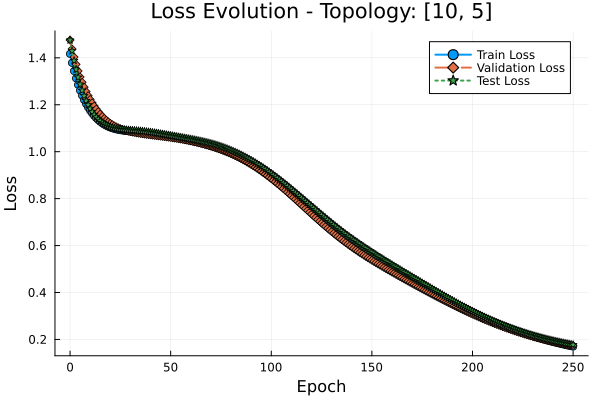

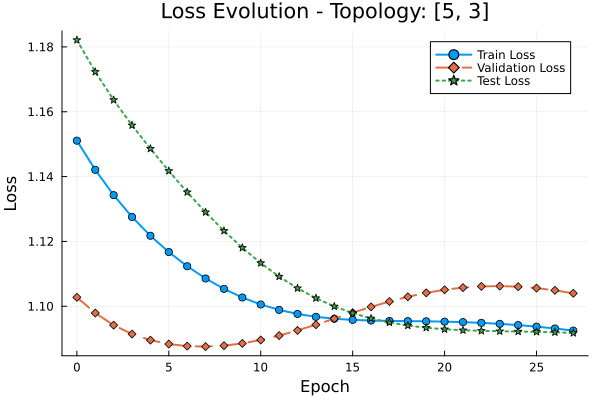

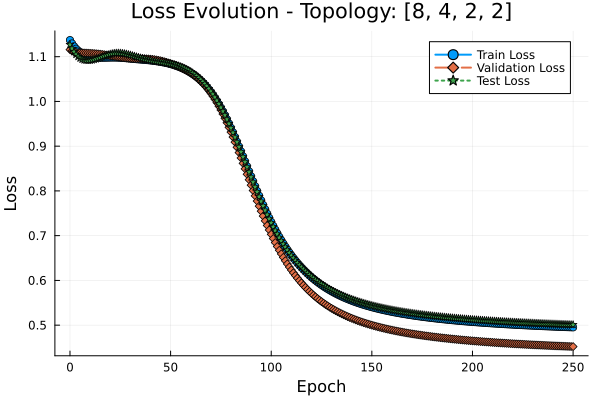

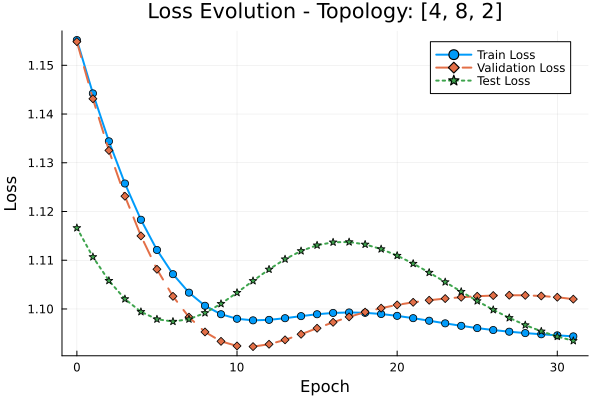

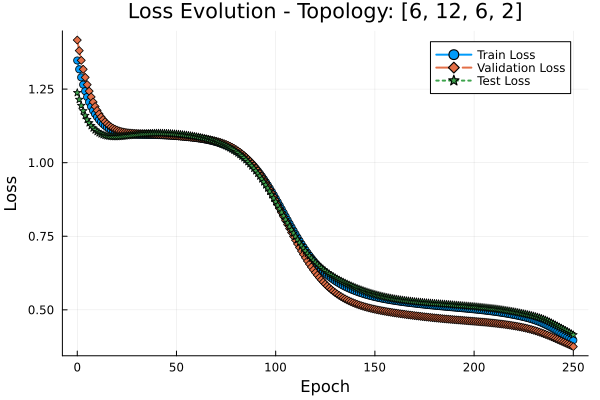

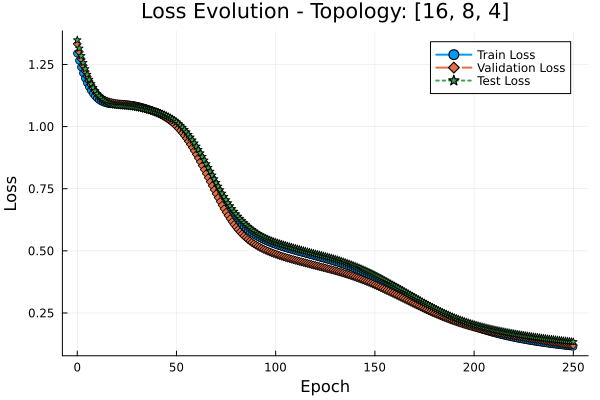

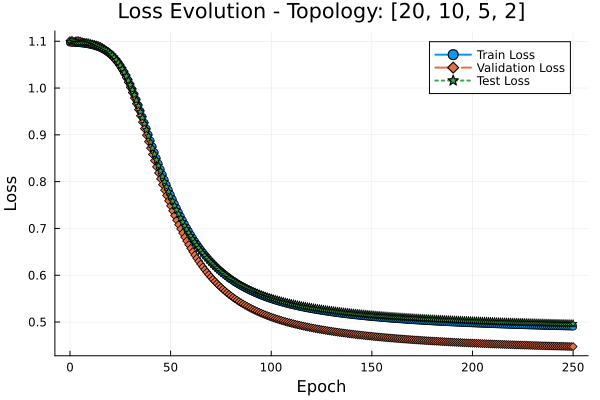

In [11]:

# We train mre architectures and store all results
# We will plot all losses one plot for each model
# --- List of architectures to try ---
architectures = [
    [10, 5],
    [4, 8, 2],
    [6, 12, 6, 2] ,
    [16, 8, 4],
    [8, 4, 2, 2],
    [20, 10, 5, 2] , 
    [5,3]  
]

# --- Store all results ---
results = Dict{String, Tuple{Vector{Float32}, Vector{Float32}, Vector{Float32}}}()


for topo in architectures
    println("\nTraining architecture: ", topo)
    finalAnn, trainLoss, valLoss, testLoss = trainClassANN(
        topo,
        (train_inputs, train_targets),
        validationDataset = (val_inputs, val_targets),
        testDataset = (test_inputs, test_targets),
        maxEpochs = 250,
        learningRate = 0.01,
        showText = true
    )
    results[string(topo)] = (trainLoss, valLoss, testLoss)
end
# results = [(topology1, (trainLoss1, valLoss1, testLoss1)), 
#            (topology2, (trainLoss2, valLoss2, testLoss2)), ...]



# --- Plotting all losses one plot for each model---
for (topology, (trainLoss, valLoss, testLoss)) in results
    epochs = 0:length(trainLoss)-1  # include cycle 0

    p = plot(epochs, trainLoss, label="Train Loss", lw=2, marker=:circle)
    
    if !isempty(valLoss)
        plot!(p, epochs, valLoss, label="Validation Loss", lw=2, linestyle=:dash, marker=:diamond)
    end
    
    if !isempty(testLoss)
        plot!(p, epochs, testLoss, label="Test Loss", lw=2, linestyle=:dot, marker=:star)
    end

    xlabel!("Epoch")
    ylabel!("Loss")
    title!("Loss Evolution - Topology: $(topology)")
    plot!(legend=:topright)
    
    display(p)  # show the plot
end


### Question 3.2
> ❓ Has the test error always decreased or has there come a point where it has started to increase?

`No. The error has increased with some of the topologies at some point. In some of the topologies, at some point like in topologies [[5,3],[4,8,2]] the test error decreases for some epochs then it increases again.`

### Question 3.3
> ❓ How do the 3 precision values evolve?

Precision per each target class or per each dataset?
`The training accuracy and the validation accuracy always increase. However, the test accuracy starts at a low value, then it decrase a little bit  and finally, the ANN starts to generalize its knowledge and the test accuracy increases.`

### Question 3.4
> ❓ Which criteria usually stop the training? Why?

`Half of the times the stop criteria is the early stopping, which happens because the validation loss does not improve for 20 epochs. The other half of the times, the training reachs the maximun number of training epochs.`

### Question 3.5
> ❓ To which cycle does the ANN returned by the function correspond? 

`Topology | Cycle

---

[10, 5] | 100

[4, 8, 2] | 100

[6, 12, 6, 2] | 14

[16, 8, 4] | 26

[8, 4, 2, 2] | 14

[20, 10, 5, 2] | 100

[5, 3] | 7
`